# USED CLAUDE FOR ASSISTANCE


---

## **Part 1 — Exploring Different Modalities / Representations of Network Traffic**

Synthetic network traffic generation is useful for many applications such as dataset augmentation, network testing, and resource management. Many existing generation methods treat traffic generation as either a time-series prediction task or an autoregressive modeling task. In these approaches, models are trained directly on structured representations of packets—one common example is **nPrint**, a tabular format that encodes packet header fields from PCAP traces into machine-learning-friendly numerical vectors.

In an **nPrint**, each row represents one packet in a trace. The entire nPrint file (a large CSV) represents all packets of that trace in sequential order. Header fields are encoded using one-hot–like binary indicators (e.g., `1`, `0`, or `01`), making them easy to feed into ML models.

However, general-purpose ML models—even advanced time-series architectures and transformers—often struggle to capture the *complex dependencies* present in real network traffic:

* **Local dependencies**: relationships among columns within a single row (i.e., dependencies among header fields of a single packet).
* **Global dependencies**: relationships across rows (i.e., the evolution of packets within the same flow).
  For example: if the first packet of a flow uses TCP, the second packet in that same flow should also be TCP; sequence numbers, flags, and flow identifiers evolve in structured ways over time.

While sequential ML models struggle with these multi-scale dependencies, **vision models** (e.g., diffusion models) excel at capturing both local and global structure when data is presented spatially—like an image. By converting nPrint traces into 2D PNG images, we can take advantage of the strong representational capabilities of image models and generate synthetic traffic using visual generative approaches.

---

### **Your Task for Part 1**

In this part of the assignment, you will:

1. **Inspect the raw nPrint files** (found in the `real_nprints` directory).
2. **Understand how each CSV row and column corresponds to packet-level metadata.**
3. **Follow the provided conversion pipeline** that transforms these nPrint CSVs into PNG image representations suitable for use with diffusion models and other visual architectures.
4. **Take an already generated set of image-representation of images and convert them back into nprint representation for downstream task utilization**

This will help you understand why converting network traces to images can unlock generative modeling capabilities that traditional ML approaches struggle with.

Q1:
First, download and unzip the data you will need from (https://drive.google.com/file/d/1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi/view?usp=sharing)
In your own words, describe how an nPrint CSV encodes a network trace.
Why might a 2D image representation capture structural relationships that a row-by-row CSV cannot?

An nPrint csv has different rows for different packets being sent in that order. It has 1088 different columns with information for fields such as port information spanning over several columns. Each column only represents one bit and field has a set length of how many bits are needed meaning every row is aligned with the all other rows. Each cell has a value of -1, 0, or 1. -1 means this field doesn't exist in that kind of packet/row. 0 or 1 is the value in the cell contributing to the total value of a category of data. But this data is all about network traffic and the payload contents are encrypted so we can't see them. When the rows are stacked into an image, we're able to see a bit of a timeline of a flow. It's more intuitive for us to look at a visual representation of a flow than to scroll through a csv. This is almost like color-coding cells in an excel sheet and scrolling down. Structurally, we are able to immediately see which columns are being used and which columns experience fluctuating data. The same goes for machines that are trying to train on this data. They can break down the image into pixels and understand patterns in this way instead of reading values in isolation.

=== netflix_1024_1: 1024 packets x 1088 bit-columns ===
{-1: 0.665, 0: 0.218, 1: 0.117}
TCP packets: 1024, UDP packets: 0
packet 1: {'ipv4_ver': 4, 'ipv4_hl': 5, 'ipv4_tl': 64, 'ipv4_ttl': 64, 'ipv4_proto': 6, 'tcp_sprt': 58867, 'tcp_dprt': 443, 'tcp_syn': 1, 'tcp_ackf': 0, 'udp_sport': None, 'udp_dport': None, 'udp_len': None}

=== zoom_1024_1: 1024 packets x 1088 bit-columns ===
{-1: 0.853, 0: 0.095, 1: 0.052}
TCP packets: 0, UDP packets: 1024
packet 1: {'ipv4_ver': 4, 'ipv4_hl': 5, 'ipv4_tl': 1156, 'ipv4_ttl': 64, 'ipv4_proto': 17, 'tcp_sprt': None, 'tcp_dprt': None, 'tcp_syn': None, 'tcp_ackf': None, 'udp_sport': 34768, 'udp_dport': 8801, 'udp_len': 1136}



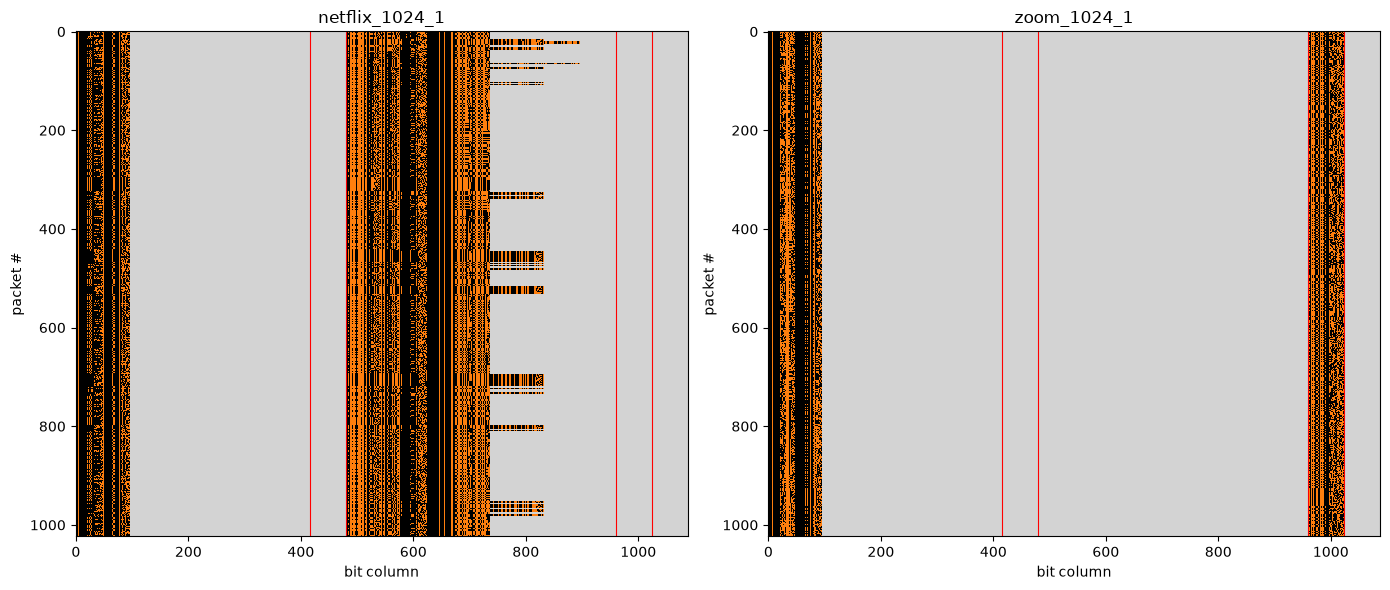

In [2]:
# Q1 exploration: what does one nPrint trace actually contain?
import pandas as pd
import numpy as np

def bits_to_int(row, field):
    """Join the bit-columns of one header field (e.g. 'ipv4_ttl_0'..'ipv4_ttl_7') into a number."""
    bits = row.filter(regex=rf"^{field}_\d+$")
    if (bits == -1).all():
        return None                      # field absent in this packet
    return int("".join(str(b) for b in bits), 2)

for name in ["netflix_1024_1", "zoom_1024_1"]:
    df = pd.read_csv(f"./nd_data/real_nprints/{name}.nprint", index_col=0)
    print(f"=== {name}: {df.shape[0]} packets x {df.shape[1]} bit-columns ===")

    # How much of the grid is 1 / 0 / -1 (absent)?
    print((df.stack().value_counts(normalize=True).round(3)).to_dict())

    # Which transport protocol does each packet use?
    is_tcp = (df.filter(like="tcp_sprt") != -1).any(axis=1)
    is_udp = (df.filter(like="udp_sport") != -1).any(axis=1)
    print(f"TCP packets: {is_tcp.sum()}, UDP packets: {is_udp.sum()}")

    # Decode the first packet's header, field by field
    p = df.iloc[0]
    fields = ["ipv4_ver", "ipv4_hl", "ipv4_tl", "ipv4_ttl", "ipv4_proto",
              "tcp_sprt", "tcp_dprt", "tcp_syn", "tcp_ackf", "udp_sport", "udp_dport", "udp_len"]
    print("packet 1:", {f: bits_to_int(p, f) for f in fields})
    print()
    
# Q1: view two traces as images (rows = packets in order, columns = header bits)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, ["netflix_1024_1", "zoom_1024_1"]):
    df = pd.read_csv(f"./nd_data/real_nprints/{name}.nprint", index_col=0)
    ax.imshow(df.values, aspect="auto", interpolation="nearest",
            cmap=ListedColormap(["lightgray", "black", "tab:orange"]), vmin=-1,
vmax=1)
    for edge in [416, 480, 960, 1024]:   # IPv4 | IPv6 | TCP | UDP | ICMP
        ax.axvline(edge - 0.5, color="red", lw=0.8)
    ax.set(title=name, xlabel="bit column", ylabel="packet #")
plt.tight_layout()

Q2. Design a method for converting nPrint representations of traces (in the folder real_nprints) into image representations.
Your image representation should use only the first 1024 packets from each trace to avoid producing images that are too large.
Save the images into a folder called './nd_data/student_converted_images'

The values of 0, 1, and -1 each get their own color. To avoid any possibility of confusion, I just picked the primary colors since no other colors can be more different. -1 gets red, 0 gets green, and 1 gets blue. Any packets that are missing get white if there are fewer than 1024 packets. My picture is also exactly 1024 x 1088, so one pixel per cell. Order of the csv is also preserved since it's a timeline essentially. The images are saved as PNGs to avoid any loss of color that might come from other formats such as JPEG.

In [4]:
# Q2: my nPrint -> image method (-1 red, 0 green, 1 blue, missing packets white)
import os, glob
from PIL import Image

N_PACKETS = 1024
COLORS = {-1: (255, 0, 0),   # field absent -> red
           0: (0, 255, 0),   # bit is 0     -> green
           1: (0, 0, 255)}   # bit is 1     -> blue
PAD = (255, 255, 255)        # no packet (trace shorter than 1024) -> white

out_dir = "./nd_data/student_converted_images"
os.makedirs(out_dir, exist_ok=True)

for path in sorted(glob.glob("./nd_data/real_nprints/*.nprint")):
    grid = pd.read_csv(path, index_col=0).values[:N_PACKETS]   # first 1024 packets only

    img = np.full((N_PACKETS, grid.shape[1], 3), PAD, dtype=np.uint8)   # blank white sheet
    for value, color in COLORS.items():
        img[:len(grid)][grid == value] = color                         # paint every matching cell

    name = os.path.basename(path).replace(".nprint", ".png")
    Image.fromarray(img).save(os.path.join(out_dir, name))

print(len(os.listdir(out_dir)), "images saved")

200 images saved


In [6]:
# The following is a pre-defined script used in NetDiffusion that will convert all of the provided real nprints into image representations. Run this code and observe the output
!python ./scripts/nprint_to_png.py -i ./nd_data/real_nprints/ -o ./nd_data/real_traffic_images

Processing teams_1024_10.nprint
Processing twitch_1024_7.nprint
Processing netflix_1024_15.nprint
Processing twitter_1024_17.nprint
Processing netflix_1024_19.nprint
Processing meet_1024_18.nprint
Processing youtube_1024_6.nprint
Processing netflix_1024_2.nprint
Processing teams_1024_3.nprint
Processing zoom_1024_8.nprint
Processing meet_1024_1.nprint
Processing instagram_1024_3.nprint
Processing zoom_1024_4.nprint
Processing youtube_1024_11.nprint
Processing meet_1024_14.nprint
Processing facebook_1024_6.nprint
Processing instagram_1024_19.nprint
Processing instagram_1024_15.nprint
Processing twitch_1024_17.nprint
Processing amazon_1024_17.nprint
Processing zoom_1024_13.nprint
Processing facebook_1024_17.nprint
Processing teams_1024.nprint
Processing amazon_1024.nprint
Processing twitch_1024_15.nprint
Processing amazon_1024_2.nprint
Processing instagram_1024_17.nprint
Processing facebook_1024_8.nprint
Processing twitch_1024.nprint
Processing facebook_1024_4.nprint
Processing twitch_10

Q3: Now that you have seen how NetDiffusion converts nPrints into images, compare their method with the approach you designed in Q2. What are the advantages and disadvantages of each, especially in terms of what might help or hinder a vision model’s ability to learn?

NetDiffusion also uses red, green, and blue for colors (albeit different colors respective to 0, 1, -1).

NetDiffusion's approach
Advantages: Interestingly, upon looking at the script, they use the color for -1 (blue) as the color to fill in rows/packets that are not there for traces with fewer than 1024. This is useful since it cuts down the training for a whole new color. If a packet doesn't exist then all cells in that row are the value -1, which makes sense.

Disadvantages: They also have an alpha value to define opacity, but since all the pixels are fully solid, it doesn't really add any information, and Stable Diffusion only uses RGB anyway. On the far left, the first column stores the index of the rows, which I don't see as very useful, especially since the opacity is the value edited for this and  it wraps back around to 0 after 255 when there are 1024 rows. NetDiffusion also doesn't truncate at 1024 rows, it would just crash with any more than that, which is definitely a disadvantage.

My approach
Advantages: I don't use an alpha value, just plain RGB which aligns with the model's way of learning. I also don't have an index column so the model won't try to learn from a column that doesn't contribute anything. I also truncate after 1024 rows instead of crashing.

Disadvantages: I used white for padding which is confusing to a model because it adds a 4th color to learn during training. This makes it a bit risky when it's easier to just use the same color for -1.


---

## **Part 2 — Converting Generated Images Back Into Usable Format**

In the first part of the assignment, you explored how network traces in nPrint format can be transformed into image representations suitable for vision-based generative models. In Part 2, we focus on the reverse process: taking synthetic images produced by these models and converting them back into structured network representations.

This step is crucial because real-world applications do not operate on images—they require valid, interpretable packet traces that can be analyzed, replayed, or integrated into downstream tools.

---

### **Your Task for Part 2**

In this part of the assignment, you will:

1. **Convert generated images back into the original nPrint representation.**
   You will follow a scripted pipeline that translates pixel intensities and color channels back into binary header fields, reconstructing the packet-level structure of the trace.

2. **Apply essential post-processing techniques to correct errors introduced by diffusion models.**
   Generated images are rarely perfect—vision models may introduce color drift, pixel misalignment, noise, or structural artifacts.
   You will observe how heuristic correction, formatting enforcement, and reconstruction steps ensure that the converted nPrints become:

   * syntactically valid,
   * structurally consistent,
   * and replayable.

Across this section, your goal is to understand **why the reverse transformation is fragile**, which types of artifacts break reversibility, and how post-processing logic helps repair or compensate for generative errors.

For simplicity of this assignment, we have trainined and generated the images for you. If you have sufficient GPU access and want to try fine-tuning the model and generating the images yourself, feel free to take a look at the public repo (https://github.com/noise-lab/NetDiffusion).


Q4: We have taken the images converted by NetDiffusion and trained a LoRA-fine-tuned Stable Diffusion model (with ControlNet) to generate synthetic traffic images for you. These generated samples are stored in generated_traffic_images/.
Compare these generated images visually with the real images you saw earlier in real_traffic_images/.

Do you notice anything different between the real and generated traffic images? What immediately stands out as potentially problematic if we attempt to convert these generated images back into nPrint format? (Descriptive Only)

For one, the generated images are blurred/lower in quality so the bits are not precise at all. This means the generated images have lines that sometimes fade into another color creating colors that are not just representative of the 3 values of 0, 1, and -1, it has in between colors of all ranges. The generated lines also are not straight and bleed into other columns. This makes it very difficult to assign values to random in between colors and lines.

Q5: If you were to design a method to convert generated images back into nPrints, how would you do it? Explain your approach and describe how your method addresses the concerns you raised in Q4. (Descriptive only)

In regards to the colors that are in between the 3 assigned colors, for each bit I would assess its RGB value and assign one of the 3 colors based on which one is closest to the generated color. For colors that are equally in between 2 colors, I would assess the color in the context of other columns. For instance, if columns for UDP are assigned one color, the columns for TCP should not be filled in. As for bleeding lines, if the other pixels in the field are all filled in (for example if a port row is all one value), then any other pixels in that column that are a different color should be colored the same. For conversion to nPrints, the headers across all nPrints are all the same so the 1088 columns would each receive the same headers as other nPrints. As for rows that are entirely -1, they will not be added as real packets since Q3 shows that NetDiffusion adds the -1 color for filling. Lastly, doing a validity check on the nPrint via checking things such as: each packet is either TCP or UDP, port values stay consistent, and making sure every cell is either 0, 1, or -1.

Below are a set of pre-written scripts that perform the necessary post-generation augmentation and processing on the synthetic images you obtained from the diffusion model. These scripts handle tasks such as color normalization/augmentation and conversion from generated images back into nPrint format.
(The PCAP step is optional — you may run it if you are interested in observing or replaying the reconstructed traffic.)

In [7]:
# Step 1: Color Augmentation
!python ./scripts/color_processor.py \
  --input_dir="./nd_data/generated_traffic_images" \
  --output_dir="./nd_data/color_corrected_generated_traffic_images"

Processed 100 images.


In [8]:
# Step 2: Image-to-nPrint Conversion
!python ./scripts/image_to_nprint.py \
  --org_nprint ./scripts/column_example.nprint \
  --input_dir ./nd_data/color_corrected_generated_traffic_images \
  --output_dir ./nd_data/generated_nprint

Processing ./nd_data/color_corrected_generated_traffic_images/teams_5.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_5.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/twitch_3.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/twitch_3.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/zoom_7.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/zoom_7.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/zoom_6.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/zoom_6.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/twitch_2.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/twitch_2.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/teams_4.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_4.nprint
Processing ./nd_data/color_corrected_generated_traffic_images/teams_6.png with size 1088 x 1024
Saved ./nd_data/generated_nprint/teams_6

Q6: You may now read through the provided scripts in color_processor.py (color augmentation / normalization) and image_to_nprint.py (image → nPrint reconstruction).
How do the post-processing methods implemented in these scripts compare to the approach you proposed in Q5?
Describe the pros and cons of both methods and highlight any differences in design philosophy, robustness, or assumptions.

Upon looking at the scripts, their approach is a lot simpler than mine. color_processor.py goes pixel by pixel and forces each one to be red, green, or blue, and image_to_nprint.py then reads those exact colors back into 1, 0, and -1 using the column names from a reference nprint. Neither script looks at neighboring pixels or knows anything about packets, fields, or protocols.

An advantage of this is that the scripts don't care what kind of packet they're converting. For instance, an ICMP or IPv6 packet gets converted the same as a TCP or UDP one, so nothing is biased toward the most common traffic. My method makes more assumptions, since my rules are built around a packet being TCP or UDP, so an unusual packet could end up getting mangled by my own corrections.

Another advantage of their approach is that it doesn't hide anything. Whatever the model drew is what ends up in the nprint, mistakes included, so when the data gets tested later you're actually measuring the diffusion model. With my method, if my rules clean everything up into valid-looking packets, it's harder to tell whether good results came from the model or from my own corrections.

The disadvantages are in how fragile the color step is. The thresholds are hardcoded numbers that were clearly tuned for this batch of images, and two of the three rules can never even run since they check if a channel is less than 0. So a greenish pixel like (94, 144, 83) passes the first if and gets painted red, which turns a 0 into a 1. Nothing warns you that this is happening, and if a future batch of images drifts a different way, the thresholds would stop fitting. This is definitely a con.

The scripts also do nothing about the bleeding I described in Q4. A pixel that bled into the wrong column just becomes a more defined wrong answer. My method fixes some of this, since a field is all-or-nothing and I can vote across a field's columns to fix a bit that was wrongly marked as -1. But it can't fix a bleed that flipped a 0 into a 1 inside a field that's present either way, so it's only a partial fix.

Overall, their scripts are designed to produce output that's syntactically valid, meaning every cell is a legal value, while my method tries for output that's semantically valid, meaning the packets could actually exist. Theirs is simpler, more predictable, and more honest about what the model produced, and mine produces cleaner data but bakes in my own assumptions.


---

# **Part 3 — Using Real and Synthetic nPrints for Application Classification**

In the previous parts, you learned how network traces can be converted between nPrint and image representations, generated using diffusion models, and reconstructed back into nPrint format.
Now, you will evaluate how useful these generated nPrints are for downstream **machine learning tasks**.

Each nPrint file—whether real or generated—is labeled with the **application** that produced the traffic (e.g., `amazon_1.nprint` means this sample came from Amazon traffic).
In this section, you will treat each **entire nPrint file as a single sample** and build a simple ML pipeline to classify application labels.

To simplify the task, you will restrict your model to use **only the first 3 packets** (3 rows) from each nPrint.
This mimics “early packet classification,” where only the beginning of a flow is available.

---


Q7:

You now have access to both `real_nprints/` and `generated_nprint/`.
Notice that in both directories, files are labeled using the application associated with that nPrint (e.g., `amazon_1.nprint`).
Treat each **nPrint file** as one sample.

**Design an ML pipeline that trains a model using *synthetic nPrints* (from `generated_nprint/`) and evaluates its performance on *real nPrints* (from `real_nprints/`) to predict the correct application label.**

Your pipeline should:

1. Use only the **first 3 packets (first 3 rows)** of each nPrint file as input features.
2. Train a classifier on real data.
3. Test the classifier on generated data.
4. Report how well the classifier performs.

We have already written the script to load the real and generated nprints into DataFrame for you.

In [9]:
import os
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Safe conversion for nPrint cell
# ---------------------------------------------------------------
def safe_convert(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()

    if x in ["0", "1", "-1"]:
        return int(x)

    if all(c in "01" for c in x) and len(x) <= 16:
        return int(x, 2)

    if x.lstrip("-").isdigit():
        return int(x)

    return 0


# ---------------------------------------------------------------
# Get original column names from a reference nPrint
# ---------------------------------------------------------------
def get_original_columns(example_path="nd_data/real_nprints"):
    first_file = glob.glob(os.path.join(example_path, "*.nprint"))[0]

    df = pd.read_csv(first_file)

    # Drop index column if present (like "Unnamed: 0")
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    return list(df.columns)


# ---------------------------------------------------------------
# Load nPrint → first 3 rows → flatten with prefixed column names
# ---------------------------------------------------------------
def load_nprint_with_colnames(path, base_cols, num_rows=3):
    df = pd.read_csv(path, dtype=str, low_memory=False)

    # Drop "Unnamed: 0" if present
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    df = df.iloc[:num_rows, :]            # first 3 packets  
    df = df.map(safe_convert)             # clean convert  

    # Build prefixed column names
    pkt_cols = []
    for pkt in range(1, num_rows + 1):
        pkt_cols.extend([f"pkt{pkt}_{c}" for c in base_cols])

    # Flatten 3×columns into 1 vector
    flat = df.values.flatten()

    return flat, pkt_cols


# ---------------------------------------------------------------
# Load entire directory into a DataFrame (with labels)
# ---------------------------------------------------------------
def load_directory_as_df(directory, base_cols):
    rows = []
    labels = []
    colnames_set = None

    for path in glob.glob(os.path.join(directory, "*.nprint")):
        label = os.path.basename(path).split("_")[0]

        flat, cn = load_nprint_with_colnames(path, base_cols)
        rows.append(flat)
        labels.append(label)

        if colnames_set is None:
            colnames_set = cn   # only set once

    df = pd.DataFrame(rows, columns=colnames_set)
    df["label"] = labels
    return df


# ---------------------------------------------------------------
# FINAL: Load real + synthetic DataFrames
# ---------------------------------------------------------------
base_cols = get_original_columns("nd_data/real_nprints")

df_synth = load_directory_as_df("nd_data/generated_nprint", base_cols)
df_real  = load_directory_as_df("nd_data/real_nprints", base_cols)

print("Synthetic DF:", df_synth.shape)
print(df_synth.head())

print("\nReal DF:", df_real.shape)
print(df_real.head())


Synthetic DF: (100, 3265)
   pkt1_ipv4_ver_0  pkt1_ipv4_ver_1  pkt1_ipv4_ver_2  pkt1_ipv4_ver_3  \
0                1                0                0                0   
1                1                0                0                0   
2                0                0                0                0   
3                0                0                0                0   
4                1                1                1                1   

   pkt1_ipv4_hl_0  pkt1_ipv4_hl_1  pkt1_ipv4_hl_2  pkt1_ipv4_hl_3  \
0               0               0               0               1   
1               0               0               0               1   
2               0               0               0               0   
3               0               0               0               0   
4               1               1               1               1   

   pkt1_ipv4_tos_0  pkt1_ipv4_tos_1  ...  pkt3_icmp_roh_23  pkt3_icmp_roh_24  \
0                0                0  ...

In [14]:
# Control: train and test BOTH on real data (5-fold CV). This is the ceiling.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_real = df_real.drop(columns="label").values
y_real = df_real["label"].values

clf = RandomForestClassifier(n_estimators=300, random_state=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(clf, X_real, y_real, cv=cv)

print("real -> real accuracy per fold:", scores.round(3))
print("mean:", round(scores.mean(), 3), " (random guessing = 0.10)")

real -> real accuracy per fold: [0.975 0.95  0.95  0.975 0.9  ]
mean: 0.95  (random guessing = 0.10)


In [15]:
# Train on synthetic, test on real
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_synth = df_synth.drop(columns="label").values
y_synth = df_synth["label"].values
X_real  = df_real.drop(columns="label").values
y_real  = df_real["label"].values

clf_a = RandomForestClassifier(n_estimators=300, random_state=0)
clf_a.fit(X_synth, y_synth)
pred_a = clf_a.predict(X_real)

print(f"train synthetic -> test real: {accuracy_score(y_real, pred_a):.3f}"
      f"   ({len(X_synth)} train, {len(X_real)} test, guessing = 0.100)")

train synthetic -> test real: 0.245   (100 train, 200 test, guessing = 0.100)


In [18]:
# Do the two prediction buckets actually line up with TCP vs UDP?
# For packet 1 of every real file, check which transport header is present
# (a field is absent when all of its bit-columns are -1).
tcp_cols = [c for c in df_real.columns if c.startswith("pkt1_tcp_sprt_")]
udp_cols = [c for c in df_real.columns if c.startswith("pkt1_udp_sport_")]

for app in sorted(df_real["label"].unique()):
    sub = df_real[df_real["label"] == app]
    n_tcp = (sub[tcp_cols] != -1).any(axis=1).sum()
    n_udp = (sub[udp_cols] != -1).any(axis=1).sum()
    print(f"{app:<10} {n_tcp:2d}/{len(sub)} files TCP   {n_udp:2d}/{len(sub)} files UDP")

amazon     20/20 files TCP    0/20 files UDP
facebook    1/20 files TCP   19/20 files UDP
instagram   1/20 files TCP   19/20 files UDP
meet        0/20 files TCP   20/20 files UDP
netflix    20/20 files TCP    0/20 files UDP
teams       0/20 files TCP   20/20 files UDP
twitch     20/20 files TCP    0/20 files UDP
twitter    20/20 files TCP    0/20 files UDP
youtube    18/20 files TCP    2/20 files UDP
zoom        1/20 files TCP   19/20 files UDP


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

labels = sorted(set(y_real))

print("=== train synthetic -> test real ===")
print(classification_report(y_real, pred_a, labels=labels, zero_division=0))

cm = pd.DataFrame(confusion_matrix(y_real, pred_a, labels=labels),
                index=labels, columns=labels)
print("rows = true app, columns = predicted app")
print(cm)

=== train synthetic -> test real ===
              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        20
    facebook       0.00      0.00      0.00        20
   instagram       0.45      0.25      0.32        20
        meet       0.50      0.10      0.17        20
     netflix       0.67      0.10      0.17        20
       teams       0.24      1.00      0.38        20
      twitch       0.00      0.00      0.00        20
     twitter       0.21      1.00      0.34        20
     youtube       0.00      0.00      0.00        20
        zoom       0.00      0.00      0.00        20

    accuracy                           0.24       200
   macro avg       0.21      0.25      0.14       200
weighted avg       0.21      0.24      0.14       200

rows = true app, columns = predicted app
           amazon  facebook  instagram  meet  netflix  teams  twitch  twitter  \
amazon          0         0          0     0        1      0       0       19   
f

In [17]:
# Is the model just learning TCP vs UDP?
import numpy as np

TCP_APPS = {"amazon", "netflix", "twitch", "twitter", "youtube"}
group = lambda a: "tcp" if a in TCP_APPS else "udp"

true_grp = np.array([group(a) for a in y_real])
pred_grp = np.array([group(a) for a in pred_a])

print("app-level accuracy      :", round((y_real == pred_a).mean(), 3))
print("protocol-level accuracy :", round((true_grp == pred_grp).mean(), 3))

app-level accuracy      : 0.245
protocol-level accuracy : 0.975


For this pipeline I treated each nprint file as one sample and took the label from the filename, using only the first 3 packets of each file, which comes out to 3264 features, and I trained a random forest with 300 trees. First, I ran a real to real-data based control to get a baseline to compare my run on synthetic data to, because without it 24.5% doesn't tell me whether the synthetic data is bad or whether naming an app from only 3 packets is just hard to begin with. The control came out to 95%, so 3 packets clearly have enough information in them and the synthetic data just isn't carrying it.

Training on synthetic and testing on real gave 24.5%, where guessing would be 10%. My answer is no, generated nprints can't replace real training data, because the model is learning on protocols rather than any other feature and thus can't name apps. Looking at the confusion matrix, almost every prediction is either teams or twitter, and those two buckets line up exactly with transport protocol. The twitter bucket is all the TCP apps (amazon, netflix, twitch, twitter, youtube) and the teams bucket is all the UDP apps (facebook, instagram, meet, teams, zoom). So I scored the same predictions again by protocol instead of by app, and while the app level accuracy is 24.5%, the protocol level accuracy is 97.5%. This makes sense since TCP versus UDP is the most obvious thing in the image, because whole regions of columns switch between having values and being all -1, while what separates netflix from twitch is small details like port numbers that it never picked up.

There are a couple of reasons it probably failed. For one, the generated packets don't even get the basic header fields right. In the dataframes printed above, the real files all have the same ipv4_ver and ipv4_hl bits since every packet is IPv4 with a standard header length, but the generated ones change from row to row. Those are the easiest bits in the whole file to copy since they never vary, so if the model can't hold those steady then it isn't going to hold the finer app specific details steady either. The classification report also shows the model honing in onto only two labels, since teams and twitter both have a recall of 1.00 but a precision of only around 0.2, while four apps are never predicted at all. Thus, the model didn't learn the ten classes, it learned one split and picked a label for each side.

I would also say my 95% control is probably higher than it should be. The 20 real files for each app may well be chunks of the same capture, so the model could be recognizing that particular session rather than the app itself, which is the same spurious correlation problem from the nPrint lecture. Overall, generated nprints can't substitute for real training data here. They do keep the coarse protocol structure so they're not useless, but they don't carry the per app signal a classifier needs, and training on them costs about 70 accuracy points compared to training on real data.